# Text Preprocessing

Tugas 2 mengolah 200 artikel detik.com (100 sport, 100 finance) dari
`data/Web-Mining/crawling_detik.csv` yang dikumpulkan pada Tugas 1. Tujuannya mengubah teks
mentah menjadi angka yang siap diproses: teks dieksplorasi, dibersihkan,
dibakukan, dilabeli kategori kata, lalu dipetakan ke vektor TF-IDF dan diringkas
dengan PCA — alur yang sama dengan materi kuliah 2.

Setiap perubahan tampil dalam kondisi sebelum dan sesudah supaya rantai
sebab-akibatnya bisa diikuti. Lokasi berkas data dirujuk dua tingkat di atas
folder notebook ini, yaitu `data/`.

## Initial Exploration

Sebelum transformasi, data diperiksa untuk mencari anomali: kelengkapan baris
dan label, karakter di luar ASCII, serta sebaran panjang teks per label. Temuan
di sini menjadi dasar aturan pembersihan pada seksi berikutnya.

In [1]:

import pandas as pd

DATA = "../../data/Web-Mining"
df = pd.read_csv(f"{DATA}/crawling_detik.csv")

checks = pd.DataFrame({
    "pemeriksaan": ["jumlah baris", "nilai kosong", "baris ganda",
                    "URL ganda", "urutan id", "jumlah per label"],
    "hasil": [len(df), df.isna().sum().sum(), df.duplicated().sum(),
              df["url"].duplicated().sum(),
              "lengkap 1-200" if list(df["id"]) == list(range(1, len(df) + 1))
              else "tidak urut",
              "; ".join(f"{k}: {v}"
                        for k, v in df["label"].value_counts().items())],
})
checks

,pemeriksaan,hasil
0,jumlah baris,200
1,nilai kosong,0
2,baris ganda,0
3,URL ganda,0
4,urutan id,lengkap 1-200
5,jumlah per label,sport: 100; finance: 100


In [2]:
df[["id", "label", "url"]].head()

,id,label,url
0,1,sport,https://sport.detik.com/basket/d-8608204/perba...
1,2,sport,https://sport.detik.com/basket/d-8296454/10-pe...
2,3,sport,https://sport.detik.com/basket/d-8353921/agar-...
3,4,sport,https://sport.detik.com/basket/d-8395308/heat-...
4,5,sport,https://sport.detik.com/basket/d-8512605/campu...


### Length by Label

Panjang karakter dan jumlah kata dirangkum per label, lalu digambar sebagai
diagram kotak. Perbandingan ini menunjukkan apakah teks sport dan finance
berbeda jauh sebelum diproses.

In [3]:

stats = (df.assign(panjang_karakter=df["isi_berita"].str.len(),
                   jumlah_kata=df["isi_berita"].str.split().str.len())
         .groupby("label")[["panjang_karakter", "jumlah_kata"]]
         .agg(["min", "median", "max"]))
stats

panjang_karakter                jumlah_kata             
                     min  median    max         min median   max
label                                                           
finance             1210  2501.0  14106         161  315.5  1930
sport                924  2409.0   5809         144  339.0   801

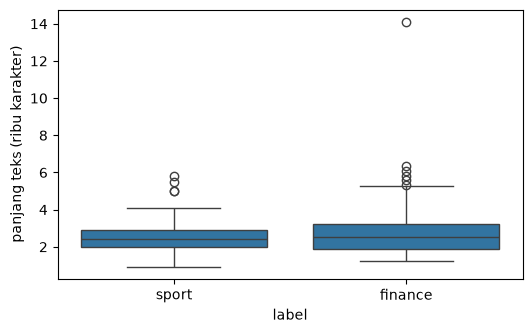

In [4]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=df, x="label", y=df["isi_berita"].str.len() / 1000, ax=ax)
ax.set_ylabel("panjang teks (ribu karakter)")
plt.show()

### Character Inventory

Karakter di luar ASCII (misal aksen hasil transliterasi nama) diinventarisasi
dulu. Aksen seperti é atau tanda hubung non-ASCII akan dianggap karakter asing
saat tokenisasi, jadi setiap kemunculannya dinormalisasi ke padanan ASCII.

In [5]:

def chars_outside_ascii(text):
    return sorted({c for c in text if ord(c) > 127})

rows = []
for _, r in df.iterrows():
    extra = chars_outside_ascii(r["isi_berita"])
    if extra:
        rows.append({"id": r["id"], "label": r["label"],
                     "karakter": " ".join(extra)})
pd.DataFrame(rows)

,id,label,karakter
0,19,sport,— …
1,57,sport,í
2,66,sport,‑
3,89,sport,➡ ️ 📺
4,91,sport,é
5,181,finance,é


In [6]:

import unicodedata

def normalize_letters(text):
    decomposed = unicodedata.normalize("NFD", text)
    text = "".join(c for c in decomposed if not unicodedata.combining(c))
    return text.replace("\u2011", "-").replace("\u2010", "-")

sample = df.set_index("id").loc[[19, 57, 66, 89, 91, 181], "isi_berita"]
pd.DataFrame({
    "id": sample.index,
    "sebelum": [t[:90] for t in sample],
    "sesudah": [normalize_letters(t)[:90] for t in sample],
})

,id,sebelum,sesudah
0,19,Bintang Memphis Grizzlies Brandon Clarke menin...,Bintang Memphis Grizzlies Brandon Clarke menin...
1,57,Kehadiran wasit asing pada fase Playoffs IBL 2...,Kehadiran wasit asing pada fase Playoffs IBL 2...
2,66,Format baru Indonesia Basketball League (IBL) ...,Format baru Indonesia Basketball League (IBL) ...
3,89,San Antonio Spurs akan menghadapi New York Kni...,San Antonio Spurs akan menghadapi New York Kni...
4,91,FIBA mempertegas komitmennya dalam mendorong p...,FIBA mempertegas komitmennya dalam mendorong p...
5,181,"Pertumbuhan sektor pariwisata, hospitality, da...","Pertumbuhan sektor pariwisata, hospitality, da..."


## Number & Punctuation Removal

Angka dan tanda baca tidak dianggap sebagai term, sehingga dipotong kasar dari
teks. Pemotongan seperti itu meninggalkan artefak: token satu huruf, dua huruf,
URL, lambang mata uang, komposit berangka, dan angka Romawi. Artefak dicacah
dulu, lalu diputuskan satu per satu berdasarkan konteksnya.

### Naive Token Count

Pemotongan kasar dibuat dulu: huruf dikecilkan dan semua selain huruf diganti
spasi sebelum token dihitung. Angka ini menjadi pembanding seberapa banyak
token hilang setelah artefak dibuang.

In [7]:

import re
from collections import Counter

def naive_tokens(text):
    return re.sub(r"[^a-z\s]", " ", text.lower()).split()

naive = [w for doc in df["isi_berita"] for w in naive_tokens(doc)]
naive_counts = Counter(naive)
single = {w: n for w, n in naive_counts.items() if len(w) == 1}
double = {w: n for w, n in naive_counts.items() if len(w) == 2}

pd.DataFrame({
    "metrik": ["token total", "kata unik", "token satu huruf",
               "token dua huruf"],
    "jumlah": [len(naive), len(naive_counts), sum(single.values()),
               sum(double.values())],
    "proporsi": ["100%", f"{100 * len(naive_counts) / len(naive):.2f}%",
                 f"{100 * sum(single.values()) / len(naive):.2f}%",
                 f"{100 * sum(double.values()) / len(naive):.2f}%"],
})

,metrik,jumlah,proporsi
0,token total,72138,100%
1,kata unik,7544,10.46%
2,token satu huruf,425,0.59%
3,token dua huruf,2878,3.99%


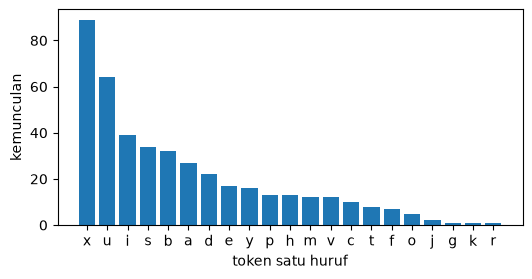

In [8]:

fig, ax = plt.subplots(figsize=(6, 2.8))
freq = sorted(single.items(), key=lambda x: -x[1])
ax.bar([w for w, _ in freq], [n for _, n in freq])
ax.set_xlabel("token satu huruf")
ax.set_ylabel("kemunculan")
plt.show()

### Single-Letter Guard

Token satu huruf hampir pasti artefak sisa kalimat (seperti huruf "x"). Konteks
beberapa di antaranya ditampilkan untuk memastikan hal ini sebelum diputuskan
dibuang.

In [9]:

def context(texts, token, window=25):
    for text in texts:
        for m in re.finditer(r"(?<![A-Za-z])" + token + r"(?![A-Za-z])",
                             text, re.IGNORECASE):
            start = max(0, m.start() - window)
            return text[start:m.end() + window].replace("\n", " ")

pd.DataFrame([{"huruf": w, "konteks": context(list(df["isi_berita"]), w)}
              for w in ["x", "u", "i", "s", "b", "a", "d", "h", "m"]])

,huruf,konteks
0,x,ia untuk meloloskan tim 3x3 ke Olimpiade mulai...
1,u,menjadi tuan rumah FIBA U16 Asia Cup 2027 dan...
2,i,nt-athlete NCAA Division I bersama Grand Canyo...
3,s,tempur di FIBA 3x3 Women's Series Xiantao Stop...
4,b,"a tertinggi Liga Jepang, B.LEAGUE Premier. Seb..."
5,a,ue Asia - East 2026. Lag a Kemenangan di level...
6,d,"esia akan gabung di Pool D. Di Pool ini, Indon..."
7,h,a MR.D.I.Y. Indonesia di H1 2026 | Aktual (dal...
8,m,1 pic.twitter.com/5AxI6j8m35 Rataan poin Adeba...


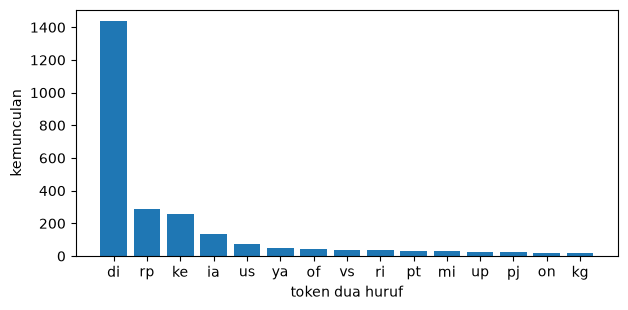

In [10]:

rows = [(w, n) for w, n in sorted(double.items(), key=lambda x: -x[1])
        if n >= 3][:15]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar([w for w, _ in rows], [n for _, n in rows])
ax.set_xlabel("token dua huruf")
ax.set_ylabel("kemunculan")
plt.show()

### Two-Letter Decision

Token dua huruf perlu diperiksa terpisah karena sebagian adalah kata singkat
nyata. Tabel konteksnya lalu dibandingkan dengan daftar stopword Sastrawi: token
yang terdaftar dipertahankan, sisanya dianggap artefak dan dipotong.

In [11]:

rows = []
for w, n in sorted(double.items(), key=lambda x: -x[1]):
    if n >= 3:
        rows.append({"token": w, "jumlah": n,
                     "konteks": context(list(df["isi_berita"]), w)})
pd.DataFrame(rows)

,token,jumlah,konteks
0,di,1436,"selama dua hari (4-5/8), di Kantor Perbasi, GB..."
1,rp,285,ut yang dikalikan dengan Rp 1.000.000 (satu ju...
2,ke,260,untuk meloloskan tim 3x3 ke Olimpiade mulai di...
3,ia,133,total 1.390 kemenangan. Ia mendapat gelar seb...
4,us,75,et kelolaan besar hingga US$ 1 triliun. Dengan...
5,ya,52,"lau one on one challenge ya bisa lah,"" ujarnya..."
6,of,46,"nt guard yang masuk Hall of Fame, Wilkens memi..."
7,vs,36,ajikan San Antonio Spurs vs New York Knicks. J...
8,ri,36,"et terbaik akan mewakili RI di Berlin, Jerman...."
9,pt,30,berada di bawah naungan PT. Ambisi Dahsyat Ge...


In [12]:

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

id_stopwords = set(StopWordRemoverFactory().get_stop_words())
tokens_2huruf = [w for w, n in double.items() if n >= 3]
(pd.DataFrame({"token": tokens_2huruf,
               "jumlah": [double[w] for w in tokens_2huruf],
               "stopword Indonesia": [w in id_stopwords
                                      for w in tokens_2huruf]})
    .sort_values("jumlah", ascending=False))

,token,jumlah,stopword Indonesia
2,di,1436,True
14,rp,285,False
0,ke,260,True
3,ia,133,True
35,us,75,False
10,ya,52,True
4,of,46,False
25,ri,36,False
7,vs,36,False
26,pt,30,False


### Format Artifacts

Empat pola artefak format dicacah: URL, komposit alfanumerik atau kata berangka,
lambang mata uang, dan angka Romawi. Pola ini dilindungi utuh sebelum simbolnya
dibuang, agar nilainya tidak ikut terbaca sebagai term.

In [13]:

url_pattern = re.compile(r"(?:https?://|www\.|pic\.twitter\.com/)\S+")
alnum_pattern = re.compile(
    r"\b(?=[A-Za-z]*\d)[A-Za-z0-9][A-Za-z0-9.*-]*\b")
currency_pattern = re.compile(
    r"\bRp\d[\d.,]*\b|\bUS\$\d[\d.,]*\b|\b\$\d[\d.,]*\b|\bRp\b|\bUS\$\b")
roman_pattern = re.compile(
    r"\b(?:iii|iv|vi{0,3}|i[ivx]{0,2}|v|x{1,3}|xi{0,3})\b", re.IGNORECASE)

n_url = sum(len(url_pattern.findall(t)) for t in df["isi_berita"])
n_alnum = sum(len(alnum_pattern.findall(t)) for t in df["isi_berita"])
n_curr = sum(len(currency_pattern.findall(t)) for t in df["isi_berita"])
n_roman = sum(len(roman_pattern.findall(t)) for t in df["isi_berita"])

pd.DataFrame({
    "jenis": ["URL", "komposit alfanumerik dan angka", "lambang mata uang",
              "angka Romawi"],
    "kemunculan": [n_url, n_alnum, n_curr, n_roman],
    "contoh": ["pic.twitter.com/ZjxXtIycwl", "3x3, U-18, 76ers, 2026, GA-604",
               "Rp, US$", "IV, VIII, XI"],
})

,jenis,kemunculan,contoh
0,URL,5,pic.twitter.com/ZjxXtIycwl
1,komposit alfanumerik dan angka,4073,"3x3, U-18, 76ers, 2026, GA-604"
2,lambang mata uang,285,"Rp, US$"
3,angka Romawi,126,"IV, VIII, XI"


In [14]:

def protect(text):
    text = url_pattern.sub(" ", text)
    text = currency_pattern.sub(" ", text)
    text = alnum_pattern.sub(" ", text)
    text = roman_pattern.sub(" ", text)
    return text.replace("\u2011", "-")

def clean_part1(text):
    text = normalize_letters(protect(text))
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    return " ".join(w for w in text.split() if len(w) >= 2)

corpus_clean_1 = [clean_part1(t) for t in df["isi_berita"]]
tokens_1 = [w.lower() for doc in corpus_clean_1 for w in doc.split()]
counts_1 = Counter(tokens_1)

pd.DataFrame({
    "kondisi": ["naif (teks asli)", "setelah proteksi dan strip (min. 2 huruf)"],
    "token total": [len(naive), len(tokens_1)],
    "kata unik": [len(naive_counts), len(counts_1)],
    "token satu huruf": [sum(single.values()),
                         sum(n for w, n in counts_1.items() if len(w) == 1)],
    "token dua huruf": [sum(double.values()),
                        sum(n for w, n in counts_1.items() if len(w) == 2)],
})

,kondisi,token total,kata unik,token satu huruf,token dua huruf
0,naif (teks asli),72138,7544,425,2878
1,setelah proteksi dan strip (min. 2 huruf),71234,7500,0,2471


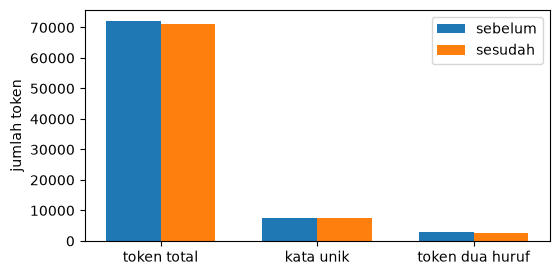

In [15]:

left = ["token total", "kata unik", "token dua huruf"]
before = [len(naive), len(naive_counts), sum(double.values())]
after = [len(tokens_1), len(counts_1),
         sum(n for w, n in counts_1.items() if len(w) == 2)]

fig, ax = plt.subplots(figsize=(6, 3))
w = 0.35
ax.bar([i - w / 2 for i in range(3)], before, width=w, label="sebelum")
ax.bar([i + w / 2 for i in range(3)], after, width=w, label="sesudah")
ax.set_xticks(range(3))
ax.set_xticklabels(left)
ax.set_ylabel("jumlah token")
ax.legend()
plt.show()

## Slang Standardization

Sebelum kata tidak baku dibakukan, dipastikan korpus ini berbahasa Indonesia:
sisipan asing dicek per kalimat dan per kata. Temuan di tahap ini menuntun
kebijakan untuk nama dan istilah yang tidak boleh ikut dinormalisasi.

In [16]:

import langid

sentences, article_ids = [], []
for _, row in df.iterrows():
    parts = [p.strip()
             for p in re.split(r"(?<=[.!?])\s+|\n+", row["isi_berita"])
             if p.strip()]
    sentences.extend(parts)
    article_ids.extend([row["id"]] * len(parts))

lang_labels = [langid.classify(s)[0] for s in sentences]
lang_counts = Counter(lang_labels)

(pd.DataFrame({"bahasa": list(lang_counts),
               "kalimat": list(lang_counts.values()),
               "proporsi": [f"{100 * k / len(sentences):.1f}%"
                            for k in lang_counts.values()]})
    .sort_values("kalimat", ascending=False))

,bahasa,kalimat,proporsi
0,id,3868,74.0%
3,ms,569,10.9%
1,en,444,8.5%
5,es,57,1.1%
19,pt,42,0.8%
11,de,38,0.7%
10,it,26,0.5%
14,jv,23,0.4%
6,pl,22,0.4%
9,sv,18,0.3%


In [17]:

en_long = []
for s, lang, aid in zip(sentences, lang_labels, article_ids):
    if lang == "en" and len(s.split()) >= 8:
        en_long.append({"id": aid, "kalimat": s})
pd.DataFrame(en_long).assign(kalimat=lambda d: d["kalimat"].str[:96] + "...")

,id,kalimat
0,2,"Semasa kariernya, Brown memimpin Denver Nugget..."
1,4,| Wilt Chamberlain | 100 | 1962-03-02 | PHW |...
2,4,| Bam Adebayo | 83 | 2026-03-10 | MIA |...
3,4,| Kobe Bryant | 81 | 2006-01-22 | LAL |...
4,4,| Wilt Chamberlain | 78 | 1961-12-08 | PHW |...
5,4,| Wilt Chamberlain | 73 | 1962-11-16 | SFW |...
6,4,| Wilt Chamberlain | 73 | 1962-01-13 | PHW |...
7,4,| Wilt Chamberlain | 72 | 1962-11-03 | SFW |...
8,4,| Joel Embiid | 70 | 2024-01-22 | PHI |...
9,4,| Devin Booker | 70 | 2017-03-24 | PHO |...


### Word Probe

`langid` dilatih untuk teks panjang; pada kata tunggal pendek hasilnya sering
bias. Beberapa kata Indonesia yang sangat umum dicoba satu per satu sebagai
baseline — tabel di bawah menunjukkan label yang seharusnya jelas tetapi keliru.
Inilah alasan deteksi per-kata tidak dipakai.

In [18]:

probe = ["dan", "di", "ke", "dalam", "pada", "akan", "juga", "satu", "tim",
         "karena", "itu", "ini", "pemerintah", "sepak", "bola", "bank",
         "saham", "untuk"]
pd.DataFrame({"kata": probe,
              "hasil langid": [langid.classify(w)[0] for w in probe]})

,kata,hasil langid
0,dan,en
1,di,en
2,ke,en
3,dalam,en
4,pada,en
5,akan,en
6,juga,en
7,satu,en
8,tim,en
9,karena,en


In [19]:

token_in_en = Counter()
for s, lang in zip(sentences, lang_labels):
    if lang == "en" and len(s.split()) >= 8:
        token_in_en.update(re.findall(r"[A-Za-z]+", s.lower()))

corpus_words = Counter(
    w for t in df["isi_berita"] for w in re.findall(r"[A-Za-z]+", t.lower()))
cap_forms = Counter(
    w.lower() for t in df["isi_berita"]
    for w in re.findall(r"[A-Za-z]+", t) if w[0].isupper())

pd.DataFrame([{"kata": w, "di kalimat en": n, "total korpus": corpus_words[w],
               "muncul kapital": cap_forms[w]}
              for w, n in token_in_en.most_common(20)])

,kata,di kalimat en,total korpus,muncul kapital
0,wilt,9,15,15
1,chamberlain,9,14,14
2,the,5,43,34
3,of,5,46,1
4,phw,4,4,4
5,sfw,4,4,4
6,brandon,3,6,6
7,ers,2,17,0
8,pistons,2,10,10
9,knicks,2,95,95


### Name Protection

Nama diri dicacah lewat bukti kapital di tengah kalimat: kata berawal huruf
besar yang tidak memulai kalimat hampir pasti nama orang atau lembaga. Daftarnya
menjadi dasar perlindungan dari normalisasi slang dan stemming.

In [20]:

def mid_sentence(text, pos):
    i = pos - 1
    while i >= 0 and text[i] in ' \n\t"\'":(':
        i -= 1
    return i >= 0 and text[i] not in '.!?;:(\u2013\u2014'

name_counts = Counter()
raw_counts = Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        raw_counts[w.lower()] += 1
        if (len(w) >= 3 and w[0].isupper()
                and mid_sentence(text, m.start())):
            name_counts[w.lower()] += 1

pd.DataFrame({
    "metrik": ["nama diri unik", "kemunculan total",
               "nama dengan >= 3 kemunculan"],
    "jumlah": [len(name_counts), sum(name_counts.values()),
               sum(1 for n in name_counts.values() if n >= 3)],
})

,metrik,jumlah
0,nama diri unik,3091
1,kemunculan total,14332
2,nama dengan >= 3 kemunculan,1053


In [21]:

pd.DataFrame([{"nama": w, "kemunculan": n}
              for w, n in name_counts.most_common(15)])

,nama,kemunculan
0,indonesia,414
1,jakarta,274
2,jaya,175
3,ibl,159
4,pelita,150
5,nba,146
6,basketball,117
7,universitas,90
8,purbaya,90
9,spurs,84


### Slang Candidates

Kandidat slang dicari lewat kamus indoNLP: token yang berubah oleh
`replace_slang` dicatat kemunculannya. Yang bertepatan muncul kapital di tengah
kalimat kemungkinan nama, sehingga diberi tanda untuk pemeriksaan manual.

In [22]:

from indoNLP.preprocessing import replace_slang

slang_hit = Counter()
cap_hit = Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        if replace_slang(w.lower()) != w.lower():
            slang_hit[w.lower()] += 1
            if w[0].isupper() and mid_sentence(text, m.start()):
                cap_hit[w.lower()] += 1

pd.DataFrame({
    "metrik": ["token kena kamus", "kemunculan berubah",
               "kemunculan nama diri (kapital tengah kalimat)"],
    "jumlah": [len(slang_hit), sum(slang_hit.values()), sum(cap_hit.values())],
})

,metrik,jumlah
0,token kena kamus,76
1,kemunculan berubah,563
2,kemunculan nama diri (kapital tengah kalimat),274


In [23]:

rows = []
for w in sorted(slang_hit, key=lambda x: -cap_hit[x]):
    rows.append({"token": w, "kemunculan": slang_hit[w],
                 "kapital tengah": cap_hit[w],
                 "padanan kamus": replace_slang(w)})
pd.DataFrame(rows[:15])

,token,kemunculan,kapital tengah,padanan kamus
0,u,64,64,lu
1,mbg,34,32,mbak
2,sma,26,21,sama
3,gt,20,20,begitu
4,pass,13,13,pas
5,usa,11,10,usah
6,c,10,10,sih
7,m,12,9,sama
8,do,9,9,di
9,d,22,7,di


### Ambiguous Context

Enam token paling ambigu dilihat dari konteks kalimatnya. Sebagian ternyata
istilah atau nama (misal istilah basket) yang kebetulan mirip slang, sehingga
token seperti itu dikecualikan dari normalisasi.

In [24]:

pd.DataFrame([{"kata": w, "konteks": context(list(df["isi_berita"]), w)}
              for w in ["dunk", "slam", "minta", "fans", "pala", "masukin"]])

,kata,konteks
0,dunk,) - 29 poin (final) Slam Dunk Contest - Keshad...
1,slam,azers) - 29 poin (final) Slam Dunk Contest - K...
2,minta,"nton juga video ""Prabowo Minta Mendiktisaintek..."
3,fans,Kapten tim dipilih oleh fans dalam sistem vot...
4,pala,", meliputi kelapa, lada, pala, tebu, kopi, kak..."
5,masukin,"Danantara tuh, kita akan masukin ke PNBP situ...."


In [25]:

excluded_slang = {"dunk", "slam", "minta", "fans", "pala", "masukin"}
slang_changes = Counter()

def guarded_replace(text):
    changes = []
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        repl = replace_slang(w.lower())
        if repl == w.lower() or w.lower() in excluded_slang:
            continue
        before = text[max(0, m.start() - 6):m.start()]
        after = text[m.end():m.end() + 6]
        near_digit = bool(re.search(r"\d", before + after))
        byline = bool(re.search(r"\(\w{2,6}/\w{2,6}\)",
                                text[m.start() - 6:m.end() + 6]))
        looks_name = (w.isupper() or any(c.isupper() for c in w[1:])
                      or (w[:1].isupper() and w[1:].islower()
                          and mid_sentence(text, m.start())))
        two_letter = len(w) <= 2 and w.lower() not in id_stopwords
        if not (near_digit or byline or looks_name or two_letter):
            changes.append((m.start(), m.end(), repl))
            slang_changes[w.lower()] += 1
    out = list(text)
    for s, e, r in reversed(changes):
        out[s:e] = list(r)
    return "".join(out)

def clean_full(text):
    text = normalize_letters(protect(text))
    text = guarded_replace(text)
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    words = [w for w in text.split() if len(w) >= 2]
    return " ".join(w for w in words
                    if not (len(w) == 2 and w.lower() not in id_stopwords))

final_docs = [clean_full(t).split() for t in df["isi_berita"]]
post_counts = Counter(w.lower() for doc in final_docs for w in doc)

pd.DataFrame([{"kata": w, "diubah": cnt, "padanan": replace_slang(w),
               "di korpus akhir": post_counts.get(replace_slang(w), 0)}
              for w, cnt in sorted(slang_changes.items())])

,kata,diubah,padanan,di korpus akhir
0,aja,7,saja,66
1,dah,1,deh,2
2,dapet,2,dapat,177
3,gimana,1,bagaimana,45
4,gini,1,begini,1
5,gitu,9,begitu,32
6,narik,1,menarik,22
7,ngerti,1,mengerti,1
8,nggak,36,enggak,43
9,ngomong,1,mengomong,1


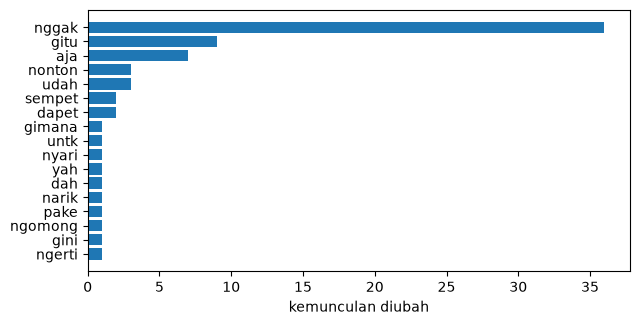

In [26]:

fig, ax = plt.subplots(figsize=(7, 3.4))
rows = sorted(slang_changes.items(), key=lambda x: -x[1])
ax.barh([w for w, _ in rows], [n for _, n in rows])
ax.set_xlabel("kemunculan diubah")
ax.invert_yaxis()
plt.show()

In [27]:

pd.DataFrame([{"kata": w, "kemunculan": post_counts[w],
               "padanan kamus": replace_slang(w)}
              for w in sorted(post_counts) if replace_slang(w) != w])

,kata,kemunculan,padanan kamus
0,akn,4,akan
1,bca,1,baca
2,bird,3,biru
3,cba,1,coba
4,dede,1,adek
5,dhe,1,deh
6,dunk,10,dong
7,fans,4,fan
8,masukin,1,memasuki
9,may,1,mau


## POS Tagging

Setiap token dilabeli kategori gramatikal sebelum stopword dibuang. Tagger
dilatih pada kalimat utuh: kata fungsi seperti *dan* atau *di* memberi konteks
untuk menebak kata di sekitarnya, dan bentuk infleksi (berimbuhan) adalah masukan
aslinya. Dipakai model RoBERTa bahasa Indonesia (tagset POSP) lewat
`transformers`. Model hanya menerima 512 subword per panggilan, jadi dokumen
panjang dipecah menjadi potongan yang diproses bergantian; dengan agregasi, satu
label keluar untuk setiap kata.

In [28]:

import logging
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")
import torch
from transformers import pipeline

logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="Asking to truncate to max_length")
warnings.filterwarnings("ignore",
                        message="Tokenizer does not support real words")
pos_pipe = pipeline(
    "token-classification",
    model="w11wo/indonesian-roberta-base-posp-tagger",
    aggregation_strategy="average",
    device=0 if torch.cuda.is_available() else -1,
)

In [29]:

wsize_budget = 400
tok = pos_pipe.tokenizer
assert tok is not None
tag_total = Counter()
sample_rows = []
annotations = []

piece_len = [[len(tok(t, add_special_tokens=False).input_ids) for t in d]
             for d in final_docs]

for doc_idx, (tokens, plen) in enumerate(zip(final_docs, piece_len),
                                         start=1):
    windows, cur, acc = [], [], 0
    for t, p in zip(tokens, plen):
        if cur and acc + p > wsize_budget:
            windows.append(cur)
            cur, acc = [t], p
        else:
            cur.append(t)
            acc += p
    if cur:
        windows.append(cur)
    tags = []
    for win in windows:
        out = pos_pipe([win], is_split_into_words=True)[0]
        for hit in out:
            tag_total[hit["entity_group"]] += 1
            tags.append(hit["entity_group"])
    annotations.append(tags)
    if doc_idx in (6, 167):
        sample_rows.extend({"id": doc_idx, "token": w, "tag": t}
                           for w, t in zip(tokens[:12], tags[:12]))

pd.DataFrame(sample_rows)

,id,token,tag
0,6,Derrick,NNP
1,6,Michael,NNP
2,6,Xzavierro,NNP
3,6,akan,ADK
4,6,memulai,VBT
5,6,karier,NNO
6,6,profesional,ADJ
7,6,di,PPO
8,6,bola,NNO
9,6,basket,NNO


In [30]:

flat = [(lbl, tag)
        for lbl, tags in zip(df["label"], annotations) for tag in tags]
dist = Counter(flat)

pd.DataFrame([{
    "tag": tag,
    "jumlah": n,
    "sport": sum(c for (l, t), c in dist.items() if t == tag and l == "sport"),
    "finance": sum(c for (l, t), c in dist.items()
                   if t == tag and l == "finance"),
} for tag, n in tag_total.most_common(20)])

,tag,jumlah,sport,finance
0,NNO,24638,10378,14260
1,NNP,11490,7749,3741
2,PPO,6981,3291,3690
3,VBT,3763,1635,2128
4,ADJ,3522,1770,1752
5,VBI,3271,1804,1467
6,ADV,2657,1212,1445
7,CCN,2404,1085,1319
8,VBP,1830,680,1150
9,ART,1592,756,836


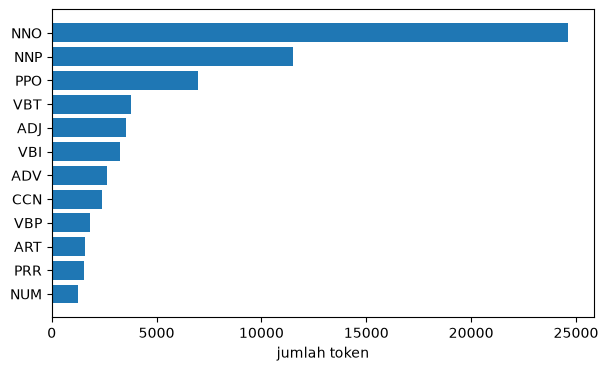

In [31]:

fig, ax = plt.subplots(figsize=(7, 4))
rows = tag_total.most_common(12)
ax.barh([t for t, _ in rows], [n for _, n in rows])
ax.set_xlabel("jumlah token")
ax.invert_yaxis()
plt.show()

## Stopword Removal

Stopword adalah kata umum yang hampir tanpa makna dan muncul di hampir semua
dokumen (misal *yang*, *di*, *dan*). Daftar Sastrawi dipakai untuk membuangnya,
sehingga kosakata mengecil dan bobot TF-IDF nanti terfokus pada kata pembeda.

In [32]:

docs_no_stop = [[w for w in d if w.lower() not in id_stopwords]
                for d in final_docs]
removed = Counter(w.lower() for d in final_docs for w in d
                  if w.lower() in id_stopwords)
before_tokens = sum(len(d) for d in final_docs)
before_uniq = len({w.lower() for d in final_docs for w in d})
after_tokens = sum(len(d) for d in docs_no_stop)
after_uniq = len({w.lower() for d in docs_no_stop for w in d})

pd.DataFrame({
    "metrik": ["token total", "kata unik", "stopword dihapus",
               "jenis stopword"],
    "sebelum": [before_tokens, before_uniq, "-", "-"],
    "sesudah": [after_tokens, after_uniq, sum(removed.values()), len(removed)],
})

,metrik,sebelum,sesudah
0,token total,70645,53759
1,kata unik,7399,7290
2,stopword dihapus,-,16886
3,jenis stopword,-,109


In [33]:

pd.DataFrame([{"kata": w, "dihapus": n}
              for w, n in removed.most_common(20)])

,kata,dihapus
0,dan,1532
1,yang,1516
2,di,1436
3,dengan,788
4,untuk,773
5,ini,739
6,dari,618
7,dalam,573
8,juga,509
9,pada,474


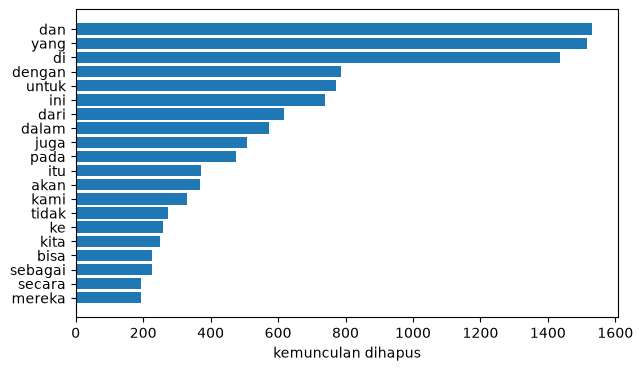

In [34]:

fig, ax = plt.subplots(figsize=(7, 4))
rows = removed.most_common(20)
ax.barh([w for w, _ in rows], [n for _, n in rows])
ax.set_xlabel("kemunculan dihapus")
ax.invert_yaxis()
plt.show()

In [35]:

sample_ids = [6, 167]
pd.DataFrame({
    "id": sample_ids,
    "sebelum": [" ".join(final_docs[i - 1][:16]) for i in sample_ids],
    "sesudah": [" ".join(docs_no_stop[i - 1][:16]) for i in sample_ids],
})

,id,sebelum,sesudah
0,6,Derrick Michael Xzavierro akan memulai karier ...,Derrick Michael Xzavierro memulai karier profe...
1,167,Presiden Prabowo Subianto mengajak Rusia untuk...,Presiden Prabowo Subianto mengajak Rusia menin...


## Stemming

Stemming memotong afiks supaya kata sekeluarga kembali ke kata dasar, misal
`menambahkan` menjadi `tambah`. Kosakata mengecil dan dokumen dengan bentuk kata
berbeda bisa saling cocok. Risikonya over-stemming (kata berbeda arti tersatu),
karena itu nama diri dilindungi lebih dulu.

In [36]:

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.Stemmer.Stemmer import Stemmer
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary
from functools import lru_cache

words = StemmerFactory().get_words()
stemmer = Stemmer(ArrayDictionary(words))

@lru_cache(maxsize=None)
def stem_word(token):
    return stemmer.stem(token)

In [37]:

protected = {w for w, n in name_counts.items()
             if n >= 5 and n >= 0.5 * raw_counts[w]}

def stem_doc(words):
    out = []
    for w in words:
        w = w.lower()
        out.append(w if w in protected else stem_word(w))
    return out

docs_stem = [stem_doc(d) for d in docs_no_stop]
st_tokens = sum(len(d) for d in docs_stem)
st_uniq = len({w for d in docs_stem for w in d})

pd.DataFrame({
    "metrik": ["token total", "kata unik"],
    "sebelum": [after_tokens, after_uniq],
    "sesudah": [st_tokens, st_uniq],
})

,metrik,sebelum,sesudah
0,token total,53759,53759
1,kata unik,7290,5200


In [38]:

stem_map = Counter()
for a, b in zip([w for d in docs_no_stop for w in d],
                [w for d in docs_stem for w in d]):
    if a != b:
        stem_map[(a, b)] += 1

pd.DataFrame([{"token": a, "stem": b, "kemunculan": n}
              for (a, b), n in stem_map.most_common(20)])

,token,stem,kemunculan
0,Indonesia,indonesia,453
1,menjadi,jadi,395
2,tersebut,sebut,344
3,Jakarta,jakarta,276
4,pemain,main,253
5,Pelita,pelita,179
6,Jaya,jaya,175
7,IBL,ibl,164
8,pertandingan,tanding,156
9,sebesar,besar,156


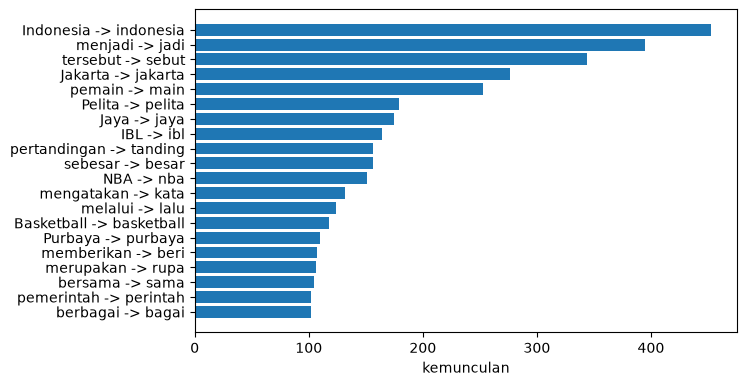

In [39]:

fig, ax = plt.subplots(figsize=(7, 4.2))
rows = stem_map.most_common(20)
ax.barh([f"{a} -> {b}" for (a, b), _ in rows], [n for _, n in rows])
ax.set_xlabel("kemunculan")
ax.invert_yaxis()
plt.show()

### Name Guard

Kandidat nama dihimpun dari aturan kapital di tengah kalimat, lalu dilindungi
bila kapital itu dominan (minimal lima kemunculan dan setengah dari semua bentuk
tulisannya). Kata dasar yang runtuh saat di-stem — `Perbasi` menjadi `basi`,
`Bali` menjadi `bal` — justru menunjukkan mengapa perlindungan ini perlu.

In [40]:

risky = [(w, stem_word(w)) for w in sorted(protected)
         if stem_word(w) != w]
pd.DataFrame(risky, columns=["nama", "runtuh menjadi"])

,nama,runtuh menjadi
0,asian,asi
1,bali,bal
2,bergizi,gizi
3,berlin,lin
4,binus,bus
5,golongan,golong
6,harapan,harap
7,kelurahan,lurah
8,kementerian,menteri
9,keuangan,uang


In [41]:

top_names = {w for w, _ in name_counts.most_common(80)}
altered = [(a, b) for (a, b), _ in stem_map.items()
           if b != a.lower() and a.lower() in top_names]
pd.DataFrame({
    "metrik": ["nama dilindungi", "kata unik nama teratas berubah"],
    "nilai": [len(protected), len(altered)],
})

,metrik,nilai
0,nama dilindungi,531
1,kata unik nama teratas berubah,2


## Unique Word Extraction

Sklearn menghitung seluruh kata unik dari token hasil stemming. Di samping total
kosakata, kata unik juga dihitung per label dan irisannya, untuk melihat seberapa
berbeda kosakata sport dan finance sebelum tabel fitur disusun.

In [42]:

from sklearn.feature_extraction.text import CountVectorizer

counter = CountVectorizer(token_pattern=r"(?u)\b\w\w+\b")
counter.fit([" ".join(d) for d in docs_stem])
vocab = counter.get_feature_names_out()

sport_vocab = {w for d, lbl in zip(docs_stem, df["label"])
               if lbl == "sport" for w in set(d)}
finance_vocab = {w for d, lbl in zip(docs_stem, df["label"])
                 if lbl == "finance" for w in set(d)}

pd.DataFrame({
    "kelompok": ["seluruh korpus", "label sport", "label finance",
                 "dipakai kedua label"],
    "kata unik": [len(vocab), len(sport_vocab), len(finance_vocab),
                  len(sport_vocab & finance_vocab)],
})

,kelompok,kata unik
0,seluruh korpus,5200
1,label sport,3318
2,label finance,3141
3,dipakai kedua label,1259


## TF-IDF Representation

TF-IDF (term frequency × inverse document frequency) memberi bobot besar pada
kata yang khas dalam satu dokumen dan bobot kecil pada kata umum, sehingga lebih
tegas daripada sekadar frekuensi. Vektor hasilnya menjadi dataset siap model dan
disimpan dalam bentuk sparse; tabel tampilan dibuat terpisah karena matriks
padatnya lebih mudah diperiksa.

In [43]:

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w\w+\b")
X = vectorizer.fit_transform([" ".join(d) for d in docs_stem])

pd.DataFrame({
    "metrik": ["dokumen", "fitur", "entri bukan nol (nnz)"],
    "nilai": [X.shape[0], X.shape[1], X.nnz],
})

,metrik,nilai
0,dokumen,200
1,fitur,5200
2,entri bukan nol (nnz),29089


### Final TF-IDF Table

Matriks sparse sulit dibaca manusia, jadi tabel di bawah diubah ke bentuk padat:
baris dokumen, kolom kata, dan label kelas di kolom terakhir. Ukuran tabel
dicetak sebagai bukti bahwa label memang ikut tercantum. Kolom kelas diberi nama
`label_kelas` karena kata *label* sendiri sudah menjadi fitur TF-IDF.

In [44]:

import numpy as np

feature_names = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(X.toarray(), index=df["id"], columns=feature_names)
df_tfidf["label_kelas"] = df["label"].values
df_tfidf.shape

(200, 5201)

In [45]:

word_freq = np.asarray(X.sum(axis=0)).ravel()
top_idx = np.argsort(-word_freq)[:10]
pd.DataFrame({"kata": feature_names[top_idx],
              "bobot total": word_freq[top_idx]})

,kata,bobot total
0,main,7.911919
1,tim,7.349862
2,jadi,7.277863
3,indonesia,6.459073
4,jaya,5.976574
5,pelita,5.963077
6,basket,5.948397
7,sebut,5.082069
8,tanding,4.931497
9,ibl,4.896272


In [46]:

df_tfidf[[feature_names[i] for i in top_idx] + ["label_kelas"]].head()

,main,tim,jadi,indonesia,jaya,pelita,basket,sebut,tanding,ibl,label_kelas
id,,,,,,,,,,,
1,0.028086,0.054784,0.000000,0.150899,0.000000,0.000000,0.183550,0.020554,0.000000,0.00000,sport
2,0.044933,0.164333,0.034540,0.000000,0.016254,0.000000,0.012235,0.008221,0.026276,0.00000,sport
3,0.000000,0.064210,0.030366,0.012633,0.357249,0.350264,0.035855,0.012045,0.038500,0.08834,sport
4,0.041024,0.026673,0.050457,0.000000,0.000000,0.000000,0.000000,0.000000,0.015993,0.00000,sport
5,0.000000,0.049142,0.030987,0.000000,0.000000,0.071485,0.000000,0.000000,0.000000,0.00000,sport


### Sparse Check

Tabel padat hanya untuk tampilan; matriks asli tetap sparse. Sebagai bukti,
dihitung jumlah sel yang nilainya lebih dari nol — hasilnya harus sama dengan
entri bukan nol (nnz) pada tabel metrik sebelumnya.

In [47]:

(df_tfidf.drop(columns="label_kelas").to_numpy() > 0).sum()

np.int64(29089)

In [48]:

col_tot = np.asarray(X.sum(axis=0)).ravel()
col_freq = np.asarray((X > 0).sum(axis=0)).ravel()
informative = [i for i in np.argsort(-col_tot) if col_freq[i] >= 2][:8]

rows = [0, 45, 99, 100, 150, 199]
sub = pd.DataFrame(
    X[rows][:, informative].toarray(),
    index=[f"{df['id'].iloc[i]}-{df['label'].iloc[i]}" for i in rows],
    columns=[feature_names[i] for i in informative],
)
sub

,main,tim,jadi,indonesia,jaya,pelita,basket,sebut
1-sport,0.028086,0.054784,0.000000,0.150899,0.000000,0.000000,0.183550,0.020554
46-sport,0.175202,0.122052,0.092352,0.076842,0.000000,0.000000,0.054523,0.036633
100-sport,0.149057,0.116298,0.036666,0.000000,0.258824,0.253764,0.032471,0.000000
101-finance,0.000000,0.000000,0.009425,0.000000,0.000000,0.000000,0.000000,0.072900
151-finance,0.018068,0.000000,0.044445,0.041603,0.000000,0.000000,0.000000,0.026445
200-finance,0.000000,0.000000,0.053381,0.000000,0.000000,0.000000,0.000000,0.084698


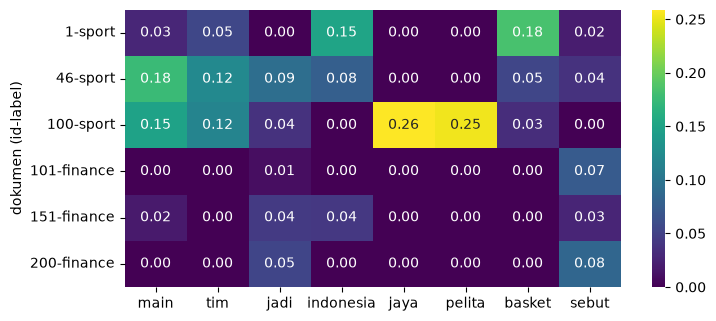

In [49]:

fig, ax = plt.subplots(figsize=(8, 3.6))
sns.heatmap(sub.values, cmap="viridis", annot=True, fmt=".2f",
            xticklabels=sub.columns.astype(str).tolist(),
            yticklabels=sub.index.astype(str).tolist(), ax=ax)
ax.set_ylabel("dokumen (id-label)")
plt.show()

In [50]:

import os
import scipy.sparse as sp

sp.save_npz(f"{DATA}/tfidf_sparse.npz", X)
pd.Series(feature_names).to_csv(f"{DATA}/tfidf_features.txt",
                                index=False, header=False)
pd.DataFrame({"id": df["id"], "label": df["label"]}).to_csv(
    f"{DATA}/tfidf_docs.csv", index=False)

pd.DataFrame({
    "berkas": ["tfidf_sparse.npz", "tfidf_features.txt", "tfidf_docs.csv"],
    "ukuran (byte)": [os.path.getsize(f"{DATA}/tfidf_sparse.npz"),
                      os.path.getsize(f"{DATA}/tfidf_features.txt"),
                      os.path.getsize(f"{DATA}/tfidf_docs.csv")],
})

,berkas,ukuran (byte)
0,tfidf_sparse.npz,186085
1,tfidf_features.txt,37605
2,tfidf_docs.csv,2101


## Dimensionality Reduction

Matriks TF-IDF berdimensi ribuan dan sparse, sehingga membawa banyak dimensi
kosong yang bakal memperlambat dan melemahkan model selanjutnya. PCA
memproyeksikan matriks ke komponen utama yang saling bebas: dua komponen dulu
digunakan untuk melihat sebaran awal, lalu seluruh komponen untuk membaca
seberapa cepat varians terkumpul.

In [51]:

from sklearn.decomposition import PCA

pca2 = PCA(n_components=2, random_state=42)
Z = pca2.fit_transform(X.toarray())
evr2 = pca2.explained_variance_ratio_

pd.DataFrame({
    "komponen": ["PC1", "PC2", "jumlah"],
    "proporsi varians": [f"{evr2[0]:.4f}", f"{evr2[1]:.4f}",
                         f"{evr2.sum():.4f}"],
})

,komponen,proporsi varians
0,PC1,0.0398
1,PC2,0.0337
2,jumlah,0.0735


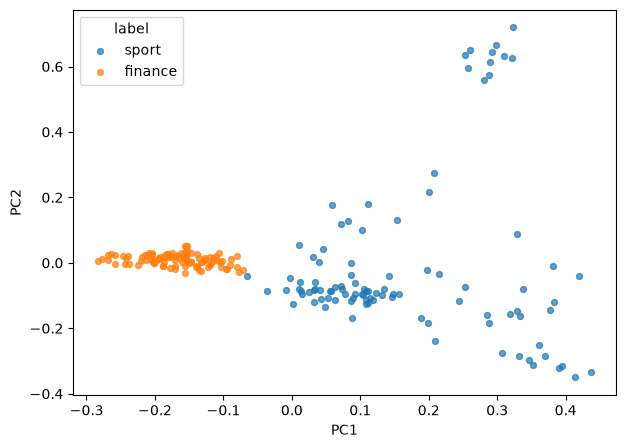

In [52]:

fig, ax = plt.subplots(figsize=(7, 5))
for label, color in [("sport", "#1f77b4"), ("finance", "#d62728")]:
    mask = (df["label"] == label).to_numpy()
    ax.scatter(Z[mask, 0], Z[mask, 1], s=18, alpha=0.7, label=label)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="label")
plt.show()

### Cumulative Variance

Tujuan akhirnya mereduksi ke dimensi di bawah 500. Karena dokumen hanya 200,
komponen maksimum yang bisa dihitung juga 200, sehingga seluruh titik pada kurva
otomatis memenuhi target itu; angka per ambang dihitung dari output di bawah.

In [53]:

max_comp = min(X.shape)
pca_all = PCA(n_components=max_comp, random_state=42).fit(X.toarray())
cum = pca_all.explained_variance_ratio_.cumsum()

pd.DataFrame([{"target varians": t,
               "komponen dibutuhkan": int((cum >= t).argmax()) + 1,
               "komponen < 500": int((cum >= t).argmax()) + 1 < 500}
              for t in [0.5, 0.8, 0.9, 0.95]])

,target varians,komponen dibutuhkan,komponen < 500
0,0.50,45,True
1,0.80,109,True
2,0.90,140,True
3,0.95,160,True


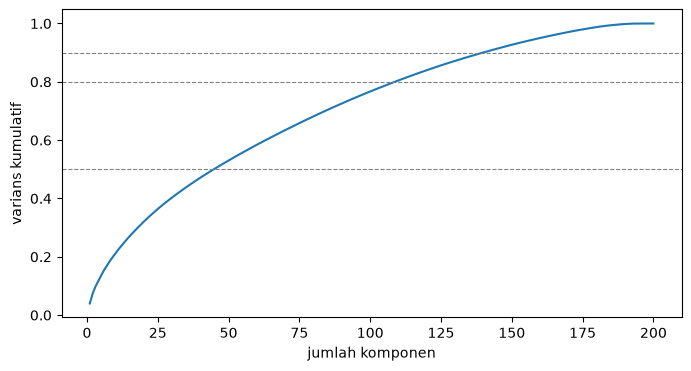

In [54]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum) + 1), cum)
for t in [0.5, 0.8, 0.9]:
    ax.axhline(t, color="gray", ls="--", lw=0.8)
ax.set_xlabel("jumlah komponen")
ax.set_ylabel("varians kumulatif")
plt.show()

In [55]:

chosen = int((cum >= 0.9).argmax()) + 1

pd.DataFrame({
    "metrik": ["fitur TF-IDF", "komponen terpilih (90%)",
               "pengurangan dimensi", "varians dua komponen"],
    "nilai": [X.shape[1], chosen,
              f"{1 - chosen / X.shape[1]:.1%}", f"{evr2.sum():.2%}"],
})

,metrik,nilai
0,fitur TF-IDF,5200
1,komponen terpilih (90%),140
2,pengurangan dimensi,97.3%
3,varians dua komponen,7.35%


## Library Insights

Pengalaman menyempurnakan sejumlah pustaka dicatat sebagai refleksi penutup.
Ketika sebuah pustaka memberi hasil yang kurang pas untuk teks berita
Indonesia, perbaikannya diterapkan langsung pada langkah terkait.

1. **`langid`** — deteksi per kata gagal untuk teks pendek: delapan belas kata
   Indonesia yang diuji banyak terlabelkan `en`, bahkan `saham` menjadi `cs` dan
   `untuk` menjadi `fi`. Penyempurnaan: deteksi dipakai hanya pada tingkat
   kalimat (74,0% kalimat berlabel Indonesia) sebagai penegas bahwa korpus ini
   berita Indonesia, bukan segmentasi per kata.

2. **`Sastrawi` stemming** — stemmer memotong hingga kata dasar dan meruntuhkan
   nama, misal `Perbasi` menjadi `basi` dan `Bali` menjadi `bal`. Sebanyak 3.091
   nama diri (14.332 kemunculan) dicacah dari kapital tengah kalimat, lalu 531
   di antaranya dilindungi sebelum stemming sehingga kosakata akhir 5.200.

3. **`Sastrawi` stopword** — daftar stopword hanya memuat kata utuh, sehingga
   artefak dua huruf yang bukan stopword tetap lolos. Penyempurnaan: tabel
   konteks menjadi dasar keputusan dengan bukti nyata — token yang tidak
   terdaftar stopword dibuang sebagai artefak.

4. **`sklearn` TfidfVectorizer** — membuang angka dan tanda baca meninggalkan
   komposit seperti `3x3`, `76ers`, `GA-604` (4.073 komposit, 5 URL, 285 mata
   uang, 126 angka Romawi), dan nama fitur `label` bentrok dengan kolom kelas.
   Penyempurnaan: pola-pola itu ditangani lebih dulu, kolom kelas diberi nama
   `label_kelas`, dan jumlah sel bukan nol dibuktikan sama dengan nnz (29.089).

5. **`transformers` RoBERTa POS** — model hanya menerima 512 subword per
   panggilan, sedangkan artikel sering lebih panjang. Penyempurnaan: teks
   dipecah menjadi potongan 400 subword, diproses bergantian, lalu diagregasi
   menjadi satu label per kata (70.645 token; tag teratas NNO, NNP, PPO, VBT,
   ADJ).

6. **`sklearn` PCA** — matriks sparse 5.200 fitur membuat varians menyebar
   tipis: dua komponen pertama hanya menahan 7,35%. Penyempurnaan: kurva
   kumulatif dipakai untuk memilih 140 komponen (90% varians, reduksi 97,3%)
   tanpa mengubah distribusi data asli.

## Conclusion

Seluruh proses dapat diringkas sebagai satu rantai sebab-akibat. Eksplorasi
menemukan artefak (URL, mata uang, komposit berangka, angka Romawi, token
satu-dua huruf) yang menentukan aturan pembersihan; deteksi bahasa menegaskan
korpus ini berita Indonesia sehingga sisipan asing dianggap nama atau istilah;
slang dibakukan dengan nama diri yang dilindungi. Sebelum stopword dibuang,
70.645 token dilabeli kategori gramatikal sebagai anotasi analisis. Stopword dan
stemming mengecilkan kosakata dari 7.399 kata unik menjadi 5.200, dan hasilnya
dipetakan menjadi matriks TF-IDF 200 dokumen x 5.200 fitur yang disimpan ke
`data/`. PCA mempertahankan hingga 90% varians dengan komponen di bawah 500,
sedangkan proyeksi dua komponen hanya menahan 7,35% varians — cukup untuk
gambaran awal sebaran, tidak untuk analisis lanjutan.